# Super Mario: calidad percibida vs. éxito comercial
## Informe final DataXperience

**Integrantes:** Santiago Bautista · Samuel Quintero · Heidy Maldonado · Kevin Perdomo

**Nuestra Pregunta:** ¿Cómo ha evolucionado la relación entre la calidad percibida (crítica y usuarios) y el éxito comercial de la saga principal de plataformas de Super Mario entre 1985 y 2023?

Esto es el informe completo del proyecto: teniendo el desarrollo de cada etapa con el código para justificar, de modo que pueda leerse y ejecutarse en Google Colab.

**Tabla de contenido**
1. Planteamiento del problema y objetivo
2. Búsqueda, obtención y justificación de los datos
3. Comprensión del conjunto de datos
4. Limpieza y preparación de los datos
5. Análisis exploratorio de datos (EDA)
6. Análisis estadístico e insights
7. Selección y comparación de modelos
8. Aplicación del modelo
9. Evaluación e interpretación del modelo
10. Conclusiones y recomendaciones
11. Referencias


## 1. Planteamiento del problema y objetivo

Un videojuego puede ser muy vendido sin ser el mejor valorado por la crítica, y también puede recibir valoraciones sobresalientes sin liderar las ventas. Esta desconexión potencial entre **calidad percibida** y **éxito comercial** es el punto de partida del proyecto.

**Objetivo del proyecto:** explorar la relación entre calidad percibida y éxito comercial en una muestra de la saga principal de plataformas de Super Mario entre 1985 y 2023, y analizar cómo esa relación se comporta a lo largo del tiempo.

**Pregunta guía:** ¿cómo ha evolucionado esa relación?

Para no dejar la pregunta principal en algo abstracto, se dividió en cinco preguntas de apoyo que estructuran el análisis exploratorio y estadístico:

1. ¿Cuál es el título con más ventas y qué score crítico tiene?
2. ¿Cuál es el título mejor valorado por la crítica y cuánto vendió?
3. ¿Venden más, en promedio, los títulos con Metascore >90 o los <90?
4. ¿Cuándo salió el título con el menor Metascore válido y cómo fueron sus ventas?
5. ¿El título más reciente con score válido mejora o empeora frente al más antiguo con score válido?

Estas preguntas se responden de manera explícita en las secciones 5 y 6.


## 2. Búsqueda, obtención y justificación de los datos

La construcción del conjunto de datos partió de una **búsqueda amplia** de la franquicia Super Mario, que inicialmente devolvió 263 resultados relacionados. Esa búsqueda amplia mezclaba subseries, spin-offs, ports, remakes y productos de géneros distintos (kart, deportes, party games, creación de niveles), por lo que no era utilizable directamente para responder la pregunta del proyecto.

**Fuentes utilizadas y su rol:**

- **Metacritic** — fuente del score crítico (Metascore, escala 0–100). Es la referencia estándar de la industria para valoración crítica agregada.
- **VGChartz** — fuente de ventas reportadas (millones de copias). Es una de las pocas fuentes públicas con series históricas de ventas por título.
- **Super Mario Wiki** — utilizada para delimitar el alcance de la serie principal de plataformas y diferenciarla de spin-offs y otras subseries de la franquicia (organización 2D/3D).
- **GitHub – `vgsales.csv`** — usado como referencia de estructura general de un dataset de ventas de videojuegos, para orientar el diseño de columnas del archivo final (no aporta los valores usados en el análisis).

**Inclusión/exclusión:** se excluyeron spin-offs, ports, remakes y juegos de creación de niveles porque pertenecen a géneros o ciclos comerciales distintos a los de un lanzamiento principal de plataformas; incluirlos rompería la comparabilidad de la unidad de análisis. El resultado de este proceso de filtrado fue una **selección curada de 16 entregas principales** (1985–2023), consistente y comparable.

**Justificación de la fuente:** se prefirió Metacritic sobre promedios de reseñas de usuarios de tiendas digitales porque su metodología de agregación es pública y estable en el tiempo, lo que permite comparar títulos de épocas muy distintas bajo el mismo criterio (con la salvedad de los cuatro títulos más antiguos, ver sección 3).


In [8]:
# Panorama antes vs. después de la limpieza (cifras de referencia del proceso de curación;
# la búsqueda amplia inicial no es reproducible con una sola consulta porque mezclaba
# subseries, spin-offs y agregados de la franquicia).

print("Búsqueda amplia (resultados relacionados): 263")
print("Selección final (entregas principales 1985-2023): 16")


Búsqueda amplia (resultados relacionados): 263
Selección final (entregas principales 1985-2023): 16


### 2.1 Trazabilidad de la selección y límite de la búsqueda amplia

La búsqueda inicial en VGChartz con el término `super mario` mostró 263 resultados en el momento de la curación. Ese conteo era dinámico y la descarga o captura de sus 263 filas no fue preservada; por rigor, **no se trata como una base cruda reproducible ni se usa en ningún cálculo**.

La evidencia reproducible de esta entrega está en `registro_seleccion_y_trazabilidad.csv`: conserva los 16 juegos incluidos, criterios de inclusión, exclusiones representativas y enlaces de fuente. El alcance correcto es una **muestra analítica intencional**, no un censo de todos los juegos de la serie.


In [9]:
import pandas as pd
# Evidencia reproducible de las decisiones de selección
registro = pd.read_csv('registro_seleccion_y_trazabilidad.csv')
print(registro['decision'].value_counts())
display(registro.query("decision == 'Incluido'")[['juego','anio','plataforma','justificacion']])


decision
Incluido    16
Excluido    12
Name: count, dtype: int64


,juego,anio,plataforma,justificacion
0,Super Mario Bros.,1985,NES,Entrega de plataformas incluida en la muestra ...
1,Super Mario Bros. 2,1988,NES,Entrega de plataformas incluida en la muestra ...
2,Super Mario Bros. 3,1990,NES,Entrega de plataformas incluida en la muestra ...
3,Super Mario World,1991,SNES,Entrega de plataformas incluida en la muestra ...
4,Super Mario 64,1996,Nintendo 64,Entrega de plataformas incluida en la muestra ...
5,Super Mario Sunshine,2002,GameCube,Entrega de plataformas incluida en la muestra ...
6,New Super Mario Bros.,2006,DS,Entrega de plataformas incluida en la muestra ...
7,Super Mario Galaxy,2007,Wii,Entrega de plataformas incluida en la muestra ...
8,New Super Mario Bros. Wii,2009,Wii,Entrega de plataformas incluida en la muestra ...
9,Super Mario Galaxy 2,2010,Wii,Entrega de plataformas incluida en la muestra ...


## 3. Comprensión del conjunto de datos

Carga el archivo limpio (`super_mario_datos_limpios.csv`), resultado del proceso de curación descrito en la sección anterior, y se inspecciona su estructura antes de cualquier análisis.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('super_mario_datos_limpios.csv')
df.head()


,Juego,Año,Plataforma,Score_critica_0_100,User_Score_0_10,Ventas_millones,Tipo_score,Fuente_dato,Metascore_valido,Grupo_score
0,Super Mario Bros.,1985,NES,86,8.2,40.24,GameRankings substitute,Metacritic article / VGChartz,False,=90 / no comparable
1,Super Mario Bros. 2,1988,NES,81,NaN,7.46,GameRankings substitute,Metacritic article / VGChartz,False,=90 / no comparable
2,Super Mario Bros. 3,1990,NES,98,NaN,17.28,GameRankings substitute,Metacritic article / VGChartz,False,=90 / no comparable
3,Super Mario World,1991,SNES,94,NaN,20.61,GameRankings substitute,Metacritic article / VGChartz,False,=90 / no comparable
4,Super Mario 64,1996,Nintendo 64,94,9.2,11.91,Metascore,Metacritic article / VGChartz,True,>90


In [20]:
print(f'Registros: {len(df)}')
print('Columnas:', list(df.columns))
display(df.dtypes)
display(df.isna().sum().rename('faltantes').to_frame())
display(df.describe(include='all').T)


Registros: 16
Columnas: ['Juego', 'Año', 'Plataforma', 'Score_critica_0_100', 'User_Score_0_10', 'Ventas_millones', 'Tipo_score', 'Fuente_dato', 'Metascore_valido', 'Grupo_score']


,0
Juego,object
Año,int64
Plataforma,object
Score_critica_0_100,int64
User_Score_0_10,float64
Ventas_millones,float64
Tipo_score,object
Fuente_dato,object
Metascore_valido,bool
Grupo_score,object


,faltantes
Juego,0
Año,0
Plataforma,0
Score_critica_0_100,0
User_Score_0_10,9
Ventas_millones,0
Tipo_score,0
Fuente_dato,0
Metascore_valido,0
Grupo_score,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Juego,16,16,Super Mario Bros.,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Año,16.0,NaN,NaN,NaN,2004.5,11.278298,1985.0,1994.75,2008.0,2012.0,2023.0
Plataforma,16,9,NES,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Score_critica_0_100,16.0,NaN,NaN,NaN,90.5625,6.010754,78.0,86.75,92.0,94.75,98.0
User_Score_0_10,7.0,NaN,NaN,NaN,9.085714,0.67436,8.1,8.7,9.2,9.55,9.8
Ventas_millones,16.0,NaN,NaN,NaN,16.91875,10.742617,5.82,7.4475,13.155,23.0375,40.24
Tipo_score,16,2,Metascore,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuente_dato,16,1,Metacritic article / VGChartz,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metascore_valido,16,2,True,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grupo_score,16,3,>90,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Descripción de las variables:**

| Variable | Descripción |
|---|---|
| `Juego` | Nombre de la entrega |
| `Año` | Año de lanzamiento original |
| `Plataforma` | Consola de lanzamiento original |
| `Score_critica_0_100` | Score crítico estandarizado a escala 0–100 |
| `User_Score_0_10` | Valoración de usuarios, escala 0–10 (tiene valores faltantes) |
| `Ventas_millones` | Copias vendidas reportadas, en millones |
| `Tipo_score` | Indica si el score proviene de Metascore directo o de una sustitución histórica (GameRankings) |
| `Fuente_dato` | Fuente de la que proviene el registro |
| `Metascore_valido` | Bandera booleana: `True` si el score es un Metascore directo y comparable |
| `Grupo_score` | Agrupación de score usada en comparaciones (`>90`, `<90`, `=90`) |

El archivo contiene **16 registros y 10 variables**. La variable `Metascore_valido` es crucial para todo el análisis: identifica los **12 títulos con Metascore directo**, frente a los **4 títulos antiguos** cuyo score histórico es en realidad una sustitución de GameRankings (Metacritic no tenía cobertura de esos títulos en su momento). Estos cuatro no se mezclan con el Metascore en comparaciones estadísticas, para no tratar un dato de una fuente distinta como si fuera equivalente.

`User_Score_0_10` tiene valores faltantes y **no fue imputado**, para no inventar información donde no existe evidencia.


## 4. Limpieza y preparación de los datos

El proceso de limpieza no fue un paso cosmético: determinó qué juegos entraban al análisis y qué comparaciones eran válidas. Consistió en cinco pasos:

1. **Delimitar la unidad de análisis** — un juego principal de plataformas de Super Mario.
2. **Retirar spin-offs y versiones** (ports, remakes, spin-offs de otros géneros) de la búsqueda amplia inicial.
3. **Estandarizar los scores críticos** a una escala común 0–100.
4. **Conservar la bandera de comparabilidad del Metascore** (`Metascore_valido`), en lugar de eliminar los títulos antiguos.
5. **Crear grupos de score** (`>90`, `<90`, `=90 / no comparable`) para las comparaciones de la sección 6.

Los títulos antiguos con score de GameRankings **no se eliminaron**: se conservaron para dar contexto histórico completo, pero se **filtran explícitamente** en cualquier análisis que exija comparabilidad directa de Metascore. Eliminarlos habría perdido información valiosa (por ejemplo, el título con más ventas de toda la selección es uno de ellos); mezclarlos sin distinción habría comparado peras con manzanas.


In [21]:
# Filtrado a los registros con Metascore directamente comparable
valid = df.loc[df['Metascore_valido'] == True].copy()

# Creación de los grupos de comparación usados en el análisis estadístico (sección 6)
valid['Grupo_metascore'] = np.select(
    [valid['Score_critica_0_100'] > 90, valid['Score_critica_0_100'] < 90],
    ['>90', '<90'], default='=90'
)

print(f'Metascore válido: {len(valid)} de {len(df)} juegos')
display(valid[['Juego', 'Año', 'Score_critica_0_100', 'Ventas_millones', 'Grupo_metascore']])


Metascore válido: 12 de 16 juegos


,Juego,Año,Score_critica_0_100,Ventas_millones,Grupo_metascore
4,Super Mario 64,1996,94,11.91,>90
5,Super Mario Sunshine,2002,92,5.91,>90
6,New Super Mario Bros.,2006,89,30.80,<90
7,Super Mario Galaxy,2007,97,12.80,>90
8,New Super Mario Bros. Wii,2009,87,30.32,<90
9,Super Mario Galaxy 2,2010,97,7.41,>90
10,Super Mario 3D Land,2011,90,12.89,=90
11,New Super Mario Bros. 2,2012,78,13.42,<90
12,New Super Mario Bros. U,2012,84,5.82,<90
13,Super Mario 3D World,2013,93,5.89,>90


### 4.1 Validaciones de calidad antes del análisis

Las siguientes comprobaciones convierten las decisiones de limpieza en reglas verificables: una fila por juego, rangos válidos y coherencia entre el tipo de score y su bandera de comparabilidad.


In [23]:
# Validaciones de calidad y consistencia
assert df['Juego'].is_unique, 'Hay juegos duplicados en la muestra final'
assert df['Año'].between(1985, 2023).all(), 'Hay un año fuera del alcance definido'
assert df['Score_critica_0_100'].between(0, 100).all(), 'Hay un score crítico fuera de rango'
assert (df['Ventas_millones'] > 0).all(), 'Hay ventas no positivas'
assert (df.loc[df['Metascore_valido'], 'Tipo_score'] == 'Metascore').all(), 'Inconsistencia de Metascore válido'
assert len(df) == 16 and df['Metascore_valido'].sum() == 12
print('Validación superada: 16 registros, sin duplicados y 12 Metascores directamente comparables.')


Validación superada: 16 registros, sin duplicados y 12 Metascores directamente comparables.


## 5. Análisis exploratorio de datos (EDA)

Se exploran dos ejes temporales — Metascore y ventas contra año de lanzamiento — para detectar tendencias o su ausencia, y se identifican los casos extremos que responden directamente a las preguntas de apoyo 1, 2 y 4 planteadas en la sección 1.


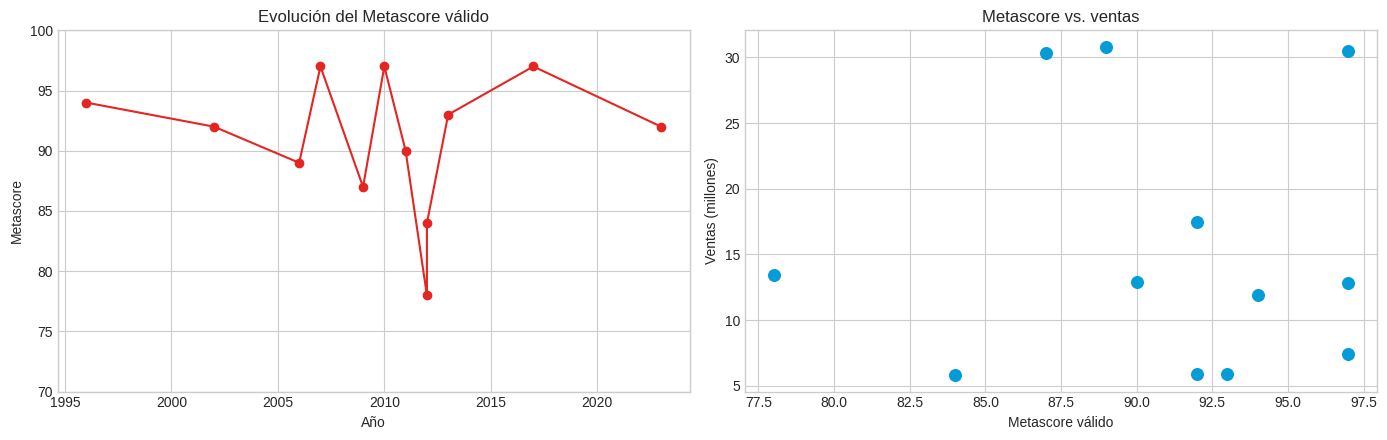

In [24]:
plotdf = valid.sort_values('Año')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(plotdf['Año'], plotdf['Score_critica_0_100'], marker='o', color='#e52521')
axes[0].set(title='Evolución del Metascore válido', xlabel='Año', ylabel='Metascore', ylim=(70, 100))
axes[1].scatter(valid['Score_critica_0_100'], valid['Ventas_millones'], s=70, color='#049cd8')
axes[1].set(title='Metascore vs. ventas', xlabel='Metascore válido', ylabel='Ventas (millones)')
plt.tight_layout(); plt.show()


**Lectura de las gráficas:** el Metascore válido se mantiene alto en varias épocas distintas, con picos de 97 en *Super Mario Galaxy*, *Super Mario Galaxy 2* y *Super Mario Odyssey*. No se observa una mejora lineal en el tiempo: *Super Mario 64* obtuvo 94 en 1996 y *Super Mario Bros. Wonder* obtuvo 92 en 2023, casi tres décadas después. Las ventas presentan picos en títulos concretos y no aumentan automáticamente con el año de lanzamiento.


In [25]:
print('Mayor venta (toda la selección):')
display(df.loc[[df['Ventas_millones'].idxmax()], ['Juego','Año','Ventas_millones','Tipo_score']])

print('Máximo Metascore válido:')
display(valid.loc[valid['Score_critica_0_100'] == valid['Score_critica_0_100'].max(),
                   ['Juego','Año','Score_critica_0_100','Ventas_millones']])

print('Menor Metascore válido:')
display(valid.loc[[valid['Score_critica_0_100'].idxmin()],
                   ['Juego','Año','Score_critica_0_100','Ventas_millones']])


Mayor venta (toda la selección):


,Juego,Año,Ventas_millones,Tipo_score
0,Super Mario Bros.,1985,40.24,GameRankings substitute


Máximo Metascore válido:


,Juego,Año,Score_critica_0_100,Ventas_millones
7,Super Mario Galaxy,2007,97,12.80
9,Super Mario Galaxy 2,2010,97,7.41
14,Super Mario Odyssey,2017,97,30.50


Menor Metascore válido:


,Juego,Año,Score_critica_0_100,Ventas_millones
11,New Super Mario Bros. 2,2012,78,13.42


**Hallazgos puntuales:**

- El **mayor vendedor** de toda la selección es *Super Mario Bros.* (1985), con **40,24 millones** reportados. Su score histórico de 86 **no es un Metascore directo** (es una sustitución de GameRankings), por lo que no se compara como tal.
- El **menor Metascore válido** es **78**, de *New Super Mario Bros. 2* (2012), que aun así reporta **13,42 millones** de ventas.

Ambos casos muestran por qué una sola métrica no resume el éxito de un juego: el mayor vendedor no es el mejor valorado, y un score relativamente bajo no impide ventas sólidas.


## 6. Análisis estadístico e insights

Se evalúa la asociación lineal entre Metascore y ventas usando únicamente los 12 registros con Metascore válido (los 4 títulos con score histórico de GameRankings quedan fuera de este cálculo, por la razón explicada en la sección 3), y se comparan los promedios de ventas entre los grupos `>90` y `<90` definidos en la sección 4. Esto responde directamente la pregunta de apoyo 3.


Correlación de Pearson: r = -0.008
R² en muestra: 0.0001
Promedio >90: 13.12 M (n=7)
Promedio <90: 20.09 M (n=4)


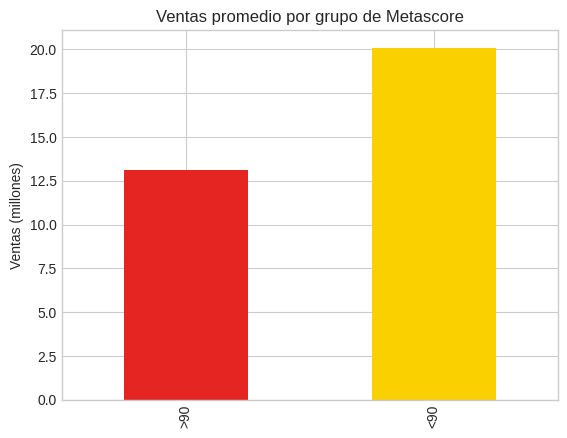

In [26]:
r = valid['Score_critica_0_100'].corr(valid['Ventas_millones'])
r2_muestra = r ** 2

high = valid.loc[valid['Score_critica_0_100'] > 90, 'Ventas_millones']
low  = valid.loc[valid['Score_critica_0_100'] < 90, 'Ventas_millones']

print(f'Correlación de Pearson: r = {r:.3f}')
print(f'R² en muestra: {r2_muestra:.4f}')
print(f'Promedio >90: {high.mean():.2f} M (n={len(high)})')
print(f'Promedio <90: {low.mean():.2f} M (n={len(low)})')

ax = pd.Series({'>90': high.mean(), '<90': low.mean()}).plot.bar(
    color=['#e52521', '#fbd000'], title='Ventas promedio por grupo de Metascore'
)
ax.set_ylabel('Ventas (millones)')
plt.show()


**Resultados:** la correlación de Pearson fue **r = -0.008**, prácticamente nula; su R² en muestra fue 0.0001. En el grupo con Metascore >90 (n=7), el promedio de ventas fue **13.12 M**; en el grupo <90 (n=4), fue **20.09 M**. El score igual a 90 se dejó fuera de esta comparación por definición de los grupos.

**Interpretación (estrictamente descriptiva):** en esta muestra, los títulos con score >90 no venden más en promedio que los títulos con score <90 — de hecho ocurre lo contrario. Esto **no significa que una valoración baja cause mayores ventas**; hay variables no observadas en este conjunto de datos que probablemente explican mejor las ventas, como el tamaño de la base instalada de la consola, el precio, la competencia en el mercado, la distribución y el marketing.


## 7. Selección del modelo y justificación

**Modelo elegido:** regresión lineal simple, usada como línea base exploratoria.

**Justificación de la elección:**

- La variable objetivo (**ventas en millones**) es numérica continua, lo que hace apropiada una regresión en lugar de un modelo de clasificación.
- El único predictor disponible que es comparable entre títulos es el **Metascore válido** (la variable `User_Score_0_10` tiene demasiados valores faltantes para usarse de forma confiable, como se señaló en la sección 3).
- Con solo 12 observaciones válidas, un modelo más complejo (por ejemplo, con múltiples predictores o términos no lineales) tendría alto riesgo de sobreajuste y sería difícil de interpretar. La regresión lineal simple es la opción más transparente para **probar si existe una señal lineal básica**, no para maximizar poder predictivo.

Es importante remarcar que este modelo **no pretende explicar causalidad ni generalizar** a toda la franquicia: es una prueba de hipótesis simple y transparente, coherente con el hallazgo descriptivo de la sección 6 (correlación prácticamente nula).


### 7.1 Comparación de dos modelos y referencia base

La consigna exige comparar al menos dos modelos. Se comparan:

1. **Regresión lineal simple (OLS):** línea base interpretable sin regularización.
2. **Ridge (`alpha=1`):** regresión lineal con regularización L2. Puede estabilizar coeficientes cuando hay pocos datos o ruido; se estandariza el predictor dentro de un `Pipeline` para evitar fuga de información.

Además se incluye **DummyRegressor** como referencia no-modelo: predice la media de entrenamiento. Un modelo útil debe superar esa referencia. Todos se evalúan con el mismo esquema Leave-One-Out (LOOCV), apropiado para las 12 observaciones comparables.


In [27]:
# Comparación reproducible: OLS vs. Ridge; Dummy es únicamente la referencia base.
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_model = valid[['Score_critica_0_100']]
y_model = valid['Ventas_millones']
loo = LeaveOneOut()
modelos = {
    'Regresión lineal (OLS)': LinearRegression(),
    'Ridge (alpha=1)': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Referencia: media': DummyRegressor(strategy='mean')
}
resultados_modelos = []
for nombre, modelo in modelos.items():
    pred_cv = cross_val_predict(modelo, X_model, y_model, cv=loo)
    resultados_modelos.append({
        'modelo': nombre,
        'MAE (millones)': mean_absolute_error(y_model, pred_cv),
        'RMSE (millones)': mean_squared_error(y_model, pred_cv) ** 0.5,
        'R² LOOCV': r2_score(y_model, pred_cv)
    })
comparacion = pd.DataFrame(resultados_modelos).set_index('modelo').round(3)
display(comparacion)


,MAE (millones),RMSE (millones),R² LOOCV
modelo,,,
Regresión lineal (OLS),9.361,10.986,-0.370
Ridge (alpha=1),9.298,10.921,-0.354
Referencia: media,8.610,10.239,-0.190


**Resultado de la comparación:** OLS obtiene MAE = **9.36 M**, RMSE = **10.99 M** y R² LOOCV = **-0.370**. Ridge obtiene MAE = **9.30 M**, RMSE = **10.92 M** y R² LOOCV = **-0.354**. La mejora de Ridge es mínima (0.06 M de MAE) y ambos quedan por debajo de la referencia de la media (MAE ≈ **8.61 M**, R² LOOCV ≈ **-0.190**).

**Decisión:** se selecciona OLS como modelo principal por su transparencia e interpretación directa. Ridge se conserva como contraste de regularización: confirma que el problema no es el sobreajuste de la pendiente, sino la ausencia de señal predictiva suficiente en el único predictor disponible. Ninguno de los dos debe utilizarse para predecir ventas reales.


## 8. Aplicación del modelo

Se ajusta la regresión lineal simple por mínimos cuadrados ordinarios sobre los 12 registros con Metascore válido.


Ventas = 16.681 + (-0.0138 × Metascore)


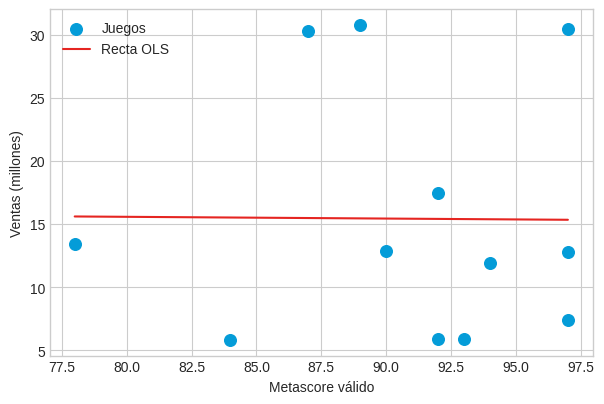

In [28]:
x = valid['Score_critica_0_100'].to_numpy(dtype=float)
y = valid['Ventas_millones'].to_numpy(dtype=float)

slope = np.cov(x, y, ddof=0)[0, 1] / np.var(x)
intercept = y.mean() - slope * x.mean()
pred = intercept + slope * x

print(f'Ventas = {intercept:.3f} + ({slope:.4f} × Metascore)')

plt.figure(figsize=(7, 4.5))
plt.scatter(x, y, s=70, color='#049cd8', label='Juegos')
plt.plot(np.sort(x), intercept + slope * np.sort(x), color='#e52521', label='Recta OLS')
plt.xlabel('Metascore válido'); plt.ylabel('Ventas (millones)'); plt.legend(); plt.show()


**Modelo estimado:**

`Ventas_millones = 16.681 + (-0.0138 × Metascore)`

La pendiente negativa es muy cercana a cero en términos prácticos: un punto adicional de Metascore no produce una predicción útil de ventas con estos datos. El intercepto (16.68 M) domina la ecuación, lo que en la práctica equivale a predecir casi siempre un valor cercano al promedio de ventas, independientemente del score.


## 9. Evaluación e interpretación del modelo

Para no evaluar el modelo únicamente con los mismos datos usados en su ajuste (lo que sobreestimaría su desempeño real), se aplica **validación leave-one-out (LOOCV)**: se ajusta el modelo con 11 juegos y se predice el restante, repitiendo el proceso para cada uno de los 12 títulos.


In [29]:
loo_pred = []
for i in range(len(x)):
    xi, yi = np.delete(x, i), np.delete(y, i)
    b1 = np.cov(xi, yi, ddof=0)[0, 1] / np.var(xi)
    b0 = yi.mean() - b1 * xi.mean()
    loo_pred.append(b0 + b1 * x[i])

loo_pred = np.array(loo_pred)
mae = np.mean(np.abs(y - loo_pred))
rmse = np.sqrt(np.mean((y - loo_pred) ** 2))
loo_r2 = 1 - np.sum((y - loo_pred) ** 2) / np.sum((y - y.mean()) ** 2)

print(f'MAE:  {mae:.2f} M')
print(f'RMSE: {rmse:.2f} M')
print(f'R² LOOCV: {loo_r2:.3f}')


MAE:  9.36 M
RMSE: 10.99 M
R² LOOCV: -0.370


**Resultados de la validación:** MAE = **9.36 millones**, RMSE = **10.99 millones**, R² de validación = **-0.370**.

**Interpretación:** un R² negativo fuera de muestra indica que **predecir siempre la media de ventas sería mejor** que usar este modelo basado únicamente en Metascore. En otras palabras, el Metascore, por sí solo, no aporta poder predictivo sobre las ventas en esta muestra.

**Conclusión sobre el modelo:** se **rechaza como herramienta práctica de predicción** con esta base de datos. Esto no es un resultado negativo del proyecto — es el hallazgo central: confirma, con evidencia cuantitativa y validada, lo que ya sugería el análisis descriptivo de la sección 6.


## 10. Conclusiones y recomendaciones

**Conclusiones:**

1. El mayor vendedor de la selección no coincide con el máximo Metascore válido: *Super Mario Bros.* (40,24 M) tiene un score histórico de 86 (no comparable directamente), mientras que el máximo Metascore válido (97) lo comparten *Galaxy*, *Galaxy 2* y *Odyssey*.
2. El grupo con Metascore >90 (n=7) **no** vende más en promedio que el grupo <90 (n=4) dentro de esta muestra (13.12 M vs. 20.09 M).
3. La correlación lineal entre Metascore y ventas es prácticamente nula (r = -0.008) y el modelo de regresión no predice bien fuera de muestra (R² LOOCV = -0.370).
4. La limpieza de datos fue determinante: hizo comparable la unidad de análisis y evitó interpretar sustitutos históricos (GameRankings) como si fueran Metascores directos.
5. La evolución del Metascore en el tiempo no es lineal: el título más reciente con score válido (*Wonder*, 2023, score 92) es ligeramente inferior al más antiguo con score válido (*Super Mario 64*, 1996, score 94).

**Limitaciones:** muestra pequeña (16 juegos, 12 con Metascore válido), ventas reportadas por una única fuente externa, `User_Score` incompleto, y variables comerciales relevantes no observadas (base instalada, precio, región, marketing).

**Recomendaciones para un siguiente corte del proyecto:**

- Ampliar la muestra a más títulos y, si es posible, a otras subseries para comprobar si los patrones se mantienen.
- Verificar las cifras de ventas con fuentes oficiales cuando existan.
- Incorporar variables que probablemente expliquen mejor las ventas: base instalada de la consola, precio de lanzamiento, región, año y gasto de marketing.
- Mejorar la cobertura de `User_Score` antes de incorporarlo a cualquier modelo, dado el volumen actual de valores faltantes.


## 11. Referencias

- Metacritic. *Every Nintendo franchise ranked*. https://www.metacritic.com/pictures/every-nintendo-franchise-ranked-worst-to-best/44/
- VGChartz. *Game database: Super Mario*. https://www.vgchartz.com/gamedb/?name=super+mario
- Super Mario Wiki. *Super Mario (series)*. https://www.mariowiki.com/Super_Mario_%28series%29
- GitHub. *vgsales.csv* (referencia de estructura para un dataset de ventas de videojuegos).
